In [19]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time

In [2]:
# ==========================================
# 1. BCOP Problem Definition (Mobile Edge Context)
# ==========================================
class BCOPProblem:
    def __init__(self, validators):
        self.validators = np.array(validators)
        self.m_max = len(validators)
        # Dynamic dimension: length of validators + 1 for block size
        self.dim = self.m_max + 1 
        
        self.minVal, self.maxVal = 5, self.m_max # maxVal is now dynamic
        self.minTrans, self.maxTrans = 50, 500
        self.theta, self.q = 1, 4
        self.K, self.B = 100, 0.5
        self.downlink, self.uplink = 1.2, 1.3
        self.xai, self.O = 0.001, 0.5
        
        self.maxSec = self.security(self.maxVal)
        self.minSec = self.security(self.minVal)
        self.maxCost = self.cost(self.validators, self.minTrans)
        minValidators = np.partition(self.validators, self.minVal)[:self.minVal]
        self.minCost = self.cost(minValidators, self.maxTrans)
        self.maxLatency = self.latency(self.maxTrans, self.maxVal, self.validators)
        top5_validators = np.partition(self.validators, -self.minVal)[-self.minVal:]
        self.minLatency = self.latency(self.minTrans, self.minVal, top5_validators)
        self.eval_cache = {}

    def clear_caches(self):
        self.eval_cache.clear()

    def security(self, m):
        return self.theta * (m ** self.q)

    def cost(self, validator_arr, n):
        return (np.sum(validator_arr)) / n

    def latency(self, n, m, validator_arr):
        minX = np.min(validator_arr)
        downlinkDelay = (n * self.B) / self.downlink
        maxCompDelay = self.K / minX
        consensusOverhead = self.xai * (n * self.B) * m
        uplinkFbDelay = self.O / self.uplink
        return downlinkDelay + maxCompDelay + consensusOverhead + uplinkFbDelay

    def evaluate(self, continuous_vector):
        m, n, sel_vals = self.decode_and_repair(continuous_vector)
        key = (m, n, tuple(sel_vals))
        
        if key in self.eval_cache:
            return self.eval_cache[key]
            
        actualLatency = self.latency(n, m, sel_vals)
        actualCost = self.cost(sel_vals, n)
        actualSecurity = self.security(m)
        
        Lnorm = (np.log10(actualLatency) - np.log10(self.minLatency)) / (np.log10(self.maxLatency) - np.log10(self.minLatency))
        Cnorm = (np.log10(actualCost) - np.log10(self.minCost)) / (np.log10(self.maxCost) - np.log10(self.minCost))
        Snorm = (np.log10(actualSecurity) - np.log10(self.minSec)) / (np.log10(self.maxSec) - np.log10(self.minSec))
        Snorm = 1 - Snorm 
        
        utility = (0.333 * Lnorm) + (0.333 * Cnorm) + (0.333 * Snorm)
        fitness = -utility 
        
        self.eval_cache[key] = fitness
        return fitness
    
    def decode_and_repair(self, continuous_vector):
        # Use self.m_max instead of hard-coded 25
        val_probs = continuous_vector[:self.m_max]
        val_bits = (val_probs > 0.5).astype(int)
        m = np.sum(val_bits)
        
        if m < self.minVal:
            zero_indices = np.where(val_bits == 0)[0]
            flip_indices = np.random.choice(zero_indices, size=(self.minVal - int(m)), replace=False)
            val_bits[flip_indices] = 1
            m = self.minVal
            
        sel_vals = self.validators[val_bits == 1]
        # n is at the last index (self.m_max)[cite: 1]
        n = int(round(continuous_vector[self.m_max]))
        n = np.clip(n, self.minTrans, self.maxTrans)
        
        return int(m), int(n), sel_vals

In [10]:
class BCGA:
    def __init__(self, problem, pop_size=150, gens=150):
        self.p = problem
        self.POP = pop_size
        self.GEN = gens
        # Chromosome = validator bits (m_max) + 9 bits for transactions (covers 50-500)
        self.chrom_length = self.p.m_max + 9 
        
    def decode(self, chrom):
        """Maps the binary array back to the BCOP continuous/discrete format."""
        val_bits = chrom[:self.p.m_max] #
        
        # Decode the last 9 bits into an integer for the transaction block size
        n_decimal = int("".join(str(int(b)) for b in chrom[self.p.m_max:]), 2) #[cite: 1]
        n = 50 + n_decimal
        
        # Create the vector expected by the evaluate function
        vec = np.zeros(self.p.dim)
        vec[:self.p.m_max] = val_bits #[cite: 1]
        vec[self.p.m_max] = n #[cite: 1]
        return vec
        
    def run(self):
        self.p.clear_caches() #[cite: 1]
        
        # Initialize binary population
        pop = np.random.randint(0, 2, (self.POP, self.chrom_length)) #[cite: 1]
        best_fit = -float('inf')
        history = []
        
        for t in range(self.GEN): #[cite: 1]
            # Evaluate fitness of decoded chromosomes
            fits = np.array([self.p.evaluate(self.decode(x)) for x in pop]) #[cite: 1]
            sort_idx = np.argsort(fits)[::-1] #[cite: 1]
            
            # Record Best Fitness
            if fits[sort_idx[0]] > best_fit: #[cite: 1]
                best_fit = fits[sort_idx[0]] #[cite: 1]
                
            # Strict Elitism: Preserve the top 5% of configurations
            elites = pop[sort_idx[:max(2, int(0.05 * self.POP))]].copy() #[cite: 1]
                
            new_pop = list(elites)
            
            # Helper function for Tournament Selection
            def tournament_select():
                idx = np.random.choice(self.POP, 3, replace=False)
                return pop[idx[np.argmax(fits[idx])]]

            # Adaptive mutation probability inversely proportional to chromosome length
            mut_prob = 1.0 / self.chrom_length
            
            while len(new_pop) < self.POP: #[cite: 1]
                p1 = tournament_select()
                p2 = tournament_select()
                
                # Single-point Crossover (80% probability)
                if random.random() < 0.8: #[cite: 1]
                    pt = np.random.randint(1, self.chrom_length - 1) #[cite: 1]
                    c1 = np.concatenate([p1[:pt], p2[pt:]]) #[cite: 1]
                    c2 = np.concatenate([p2[:pt], p1[pt:]]) #[cite: 1]
                else: 
                    c1, c2 = p1.copy(), p2.copy() #[cite: 1]
                    
                # Bit-flip Mutation (Adaptive, per bit)
                for c in [c1, c2]:
                    if len(new_pop) < self.POP:
                        # 15% chance for an individual to undergo mutation
                        if random.random() < 0.15: #[cite: 1]
                            mut_pts = np.random.rand(self.chrom_length) < mut_prob #[cite: 1]
                            c[mut_pts] ^= 1 #[cite: 1]
                        new_pop.append(c) #[cite: 1]
                    
            pop = np.array(new_pop)
            history.append(-best_fit) # Store Utility (Positive for plotting)[cite: 1]
            
        return -best_fit, history #[cite: 1]

In [11]:
# ==========================================
# 1. Base Continuous Optimizer
# ==========================================
class ContinuousOptimizer:
    def __init__(self, problem, pop_size=150, gens=150):
        self.prob = problem
        self.pop_size = pop_size
        self.gens = gens
        self.dim = problem.dim
        # Dynamic boundaries based on actual validator count
        self.bounds_min = np.array([0.0] * self.prob.m_max + [50.0])
        self.bounds_max = np.array([1.0] * self.prob.m_max + [500.0])

    def init_population(self):
        pop = np.zeros((self.pop_size, self.dim))
        pop[:, :self.prob.m_max] = np.random.uniform(0.0, 1.0, (self.pop_size, self.prob.m_max))
        pop[:, self.prob.m_max] = np.random.uniform(50.0, 500.0, self.pop_size)
        return pop

In [12]:
# ==========================================
# 2. Real Coded GA (Arithmetic Crossover + Gaussian Mutation)
# ==========================================
class RCGA(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        pop = self.init_population()
        best_fit = -float('inf')
        history = []

        for t in range(self.gens):
            fits = np.array([self.prob.evaluate(x) for x in pop])
            sorted_idx = np.argsort(fits)[::-1]
            
            if fits[sorted_idx[0]] > best_fit:
                best_fit = fits[sorted_idx[0]]
            
            # 5% Elitism
            elites_count = max(2, int(0.05 * self.pop_size))
            elites = pop[sorted_idx[:elites_count]].copy()
            new_pop = list(elites)
            
            def tournament_select():
                idx = np.random.choice(self.pop_size, 3, replace=False)
                return pop[idx[np.argmax(fits[idx])]]

            mut_prob = 1.0 / self.dim # Adaptive per-gene mutation rate
            
            while len(new_pop) < self.pop_size:
                p1, p2 = tournament_select(), tournament_select()
                
                # Arithmetic Crossover
                alpha = np.random.rand(self.dim)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = (1 - alpha) * p1 + alpha * p2
                
                # Gaussian Mutation
                for child in [c1, c2]:
                    if len(new_pop) < self.pop_size:
                        if random.random() < 0.20:
                            mask = np.random.rand(self.dim) < mut_prob
                            noise = np.random.normal(0, 0.05 * (self.bounds_max - self.bounds_min))
                            child = np.where(mask, child + noise, child)
                            child = np.clip(child, self.bounds_min, self.bounds_max)
                        new_pop.append(child)

            pop = np.array(new_pop)
            history.append(-best_fit) 
            
        return -best_fit, history

In [13]:
# ==========================================
# 3. Particle Swarm Optimization (Inertia Decay + Constriction)
# ==========================================
class PSO(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        w_max, w_min = 0.9, 0.4
        c1, c2 = 1.49618, 1.49618 
        
        pos = self.init_population()
        vel = np.zeros((self.pop_size, self.dim))
        
        pbest_pos = pos.copy()
        pbest_fit = np.array([self.prob.evaluate(p) for p in pos])
        
        gbest_idx = np.argmax(pbest_fit)
        gbest_fit = pbest_fit[gbest_idx]
        gbest_pos = pbest_pos[gbest_idx].copy()
        history = []
        
        for gen in range(self.gens):
            w = w_max - (gen / self.gens) * (w_max - w_min)
            for i in range(self.pop_size):
                r1, r2 = np.random.rand(self.dim), np.random.rand(self.dim)
                vel[i] = w * vel[i] + c1 * r1 * (pbest_pos[i] - pos[i]) + c2 * r2 * (gbest_pos - pos[i])
                pos[i] = np.clip(pos[i] + vel[i], self.bounds_min, self.bounds_max)
                
                curr_fit = self.prob.evaluate(pos[i])
                if curr_fit > pbest_fit[i]:
                    pbest_fit[i], pbest_pos[i] = curr_fit, pos[i].copy()
                    if curr_fit > gbest_fit:
                        gbest_fit, gbest_pos = curr_fit, pos[i].copy()
            history.append(-gbest_fit)
                        
        return -gbest_fit, history

In [14]:
# ==========================================
# 4. Differential Evolution (Adaptive F and CR)
# ==========================================
class DE(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        pop = self.init_population()
        fits = np.array([self.prob.evaluate(p) for p in pop])
        history = []
        best_fit = np.max(fits)
        
        for gen in range(self.gens):
            for i in range(self.pop_size):
                # Adaptive scaling factors to maintain diversity in high dims
                F = np.clip(np.random.normal(0.5, 0.3), 0.1, 1.0)
                CR = np.clip(np.random.normal(0.9, 0.1), 0.1, 1.0)
                
                best_vec = pop[np.argmax(fits)]
                r1, r2 = pop[np.random.choice(self.pop_size, 2, replace=False)]
                mutant = np.clip(best_vec + F * (r1 - r2), self.bounds_min, self.bounds_max)
                
                cross_mask = np.random.rand(self.dim) < CR
                trial = np.where(cross_mask, mutant, pop[i])
                
                trial_fit = self.prob.evaluate(trial)
                if trial_fit > fits[i]:
                    pop[i], fits[i] = trial, trial_fit
                    
            if np.max(fits) > best_fit:
                best_fit = np.max(fits)
            history.append(-best_fit)
                    
        return -best_fit, history

In [15]:
# ==========================================
# 5. Artificial Bee Colony (Increased Scout Limit)
# ==========================================
class ABC(ContinuousOptimizer):
    def run(self, limit=50): # Limit increased for deeper local search
        self.prob.clear_caches()
        pop = self.init_population()
        fits = np.array([self.prob.evaluate(p) for p in pop])
        trials = np.zeros(self.pop_size)
        history = []
        best_fit = np.max(fits)

        for gen in range(self.gens):
            for i in range(self.pop_size):
                k = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                phi = np.random.uniform(-1, 1, self.dim)
                new_sol = np.clip(pop[i] + phi * (pop[i] - pop[k]), self.bounds_min, self.bounds_max)
                
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i], trials[i] = new_sol, new_fit, 0
                else:
                    trials[i] += 1

            prob_dist = (fits - np.min(fits)) / (np.sum(fits - np.min(fits)) + 1e-9)
            for _ in range(self.pop_size):
                i = np.random.choice(self.pop_size, p=prob_dist)
                k = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                new_sol = np.clip(pop[i] + np.random.uniform(-1, 1, self.dim) * (pop[i] - pop[k]), self.bounds_min, self.bounds_max)
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i], trials[i] = new_sol, new_fit, 0
                else:
                    trials[i] += 1

            for i in range(self.pop_size):
                if trials[i] > limit:
                    # Reset scout bee respecting dynamic ranges
                    pop[i, :self.prob.m_max] = np.random.uniform(0.0, 1.0, self.prob.m_max)
                    pop[i, self.prob.m_max] = np.random.uniform(50.0, 500.0)
                    fits[i] = self.prob.evaluate(pop[i])
                    trials[i] = 0

            if np.max(fits) > best_fit:
                best_fit = np.max(fits)
            history.append(-best_fit)
                
        return -best_fit, history

In [16]:
# ==========================================
# 6. Ant Colony Optimization (Rank-based Updates)
# ==========================================
class ACO:
    def __init__(self, problem, pop_size=100, gens=150):
        self.prob = problem
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        self.prob.clear_caches()
        m_max = self.prob.m_max
        
        eta_val = np.ones((m_max, 2))
        eta_val[:, 1] = self.prob.validators / np.max(self.prob.validators)  
        eta_val[:, 0] = 1.0 - eta_val[:, 1]
        eta_trans = np.linspace(500, 50, 451) / 500.0 
        
        tau_val = np.ones((m_max, 2))
        tau_trans = np.ones(451)
        
        best_fit = -float('inf')
        history = []

        for gen in range(self.gens):
            pop_sols = []
            pop_fits = []
            
            for _ in range(self.pop_size):
                sol_vals = np.zeros(m_max)
                for i in range(m_max):
                    p = (tau_val[i] ** 1.0) * (eta_val[i] ** 2.5)
                    sol_vals[i] = np.random.choice([0, 1], p=p/p.sum())
                    
                p_t = (tau_trans ** 1.0) * (eta_trans ** 2.5)
                sol_trans_idx = np.random.choice(451, p=p_t/p_t.sum())
                
                vec = np.zeros(m_max + 1)
                vec[:m_max] = sol_vals
                vec[m_max] = 50 + sol_trans_idx
                
                fit = self.prob.evaluate(vec)
                pop_sols.append((sol_vals, sol_trans_idx))
                pop_fits.append(fit)
                
                if fit > best_fit: 
                    best_fit = fit
                    
            tau_val *= 0.85
            tau_trans *= 0.85
            
            # Rank-based Pheromone Update (Only Top 20% ants leave pheromones)
            top_indices = np.argsort(pop_fits)[::-1][:max(2, int(0.20 * self.pop_size))]
            for idx in top_indices:
                reward = 1.0 / (1.0 + (best_fit - pop_fits[idx])) 
                v, t = pop_sols[idx]
                for i in range(m_max): 
                    tau_val[i, int(v[i])] += reward
                tau_trans[int(t)] += reward

            history.append(-best_fit)

        return -best_fit, history

In [17]:
# ==========================================
# 7. Teaching-Learning-Based Optimization (TLBO)
# ==========================================
class TLBO(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        pop = self.init_population()
        fits = np.array([self.prob.evaluate(p) for p in pop])
        history = []
        best_fit = np.max(fits)
        
        for gen in range(self.gens):
            best_idx = np.argmax(fits)
            teacher = pop[best_idx]
            mean_v = np.mean(pop, axis=0)
            
            # Teaching Phase
            for i in range(self.pop_size):
                tf = np.random.randint(1, 3) 
                new_sol = np.clip(pop[i] + np.random.rand(self.dim) * (teacher - tf * mean_v), self.bounds_min, self.bounds_max)
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i] = new_sol, new_fit
            
            # Learning Phase
            for i in range(self.pop_size):
                partner = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                diff = pop[i] - pop[partner] if fits[i] > fits[partner] else pop[partner] - pop[i]
                new_sol = np.clip(pop[i] + np.random.rand(self.dim) * diff, self.bounds_min, self.bounds_max)
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i] = new_sol, new_fit
                    
            if np.max(fits) > best_fit:
                best_fit = np.max(fits)
            history.append(-best_fit)
            
        return -best_fit, history

In [18]:
# ==========================================
# 3. Experiment Engine & Plotting
# ==========================================
def plot_convergence_curves(histories, title):
    plt.figure(figsize=(12, 7))
    colors = plt.cm.get_cmap('tab10', len(histories)).colors
    
    for i, (algo_name, history) in enumerate(histories.items()):
        plt.plot(history, label=algo_name, color=colors[i], linewidth=2.5, alpha=0.8)
        
    plt.xlabel('Generations', fontsize=12, fontweight='bold')
    plt.ylabel('Utility U (Lower is Better)', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [20]:
def plot_grouped_bars(x_labels, data_dict, title, ylabel, is_fitness=True):
    n_groups = len(x_labels)
    n_algos = len(data_dict)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    index = np.arange(n_groups)
    bar_width = 0.10
    opacity = 0.85
    
    colors = plt.cm.get_cmap('tab10', n_algos).colors
    
    for i, (algo_name, values) in enumerate(data_dict.items()):
        bars = ax.bar(index + i * bar_width, values, bar_width, 
                      alpha=opacity, label=algo_name, color=colors[i], edgecolor='black', linewidth=0.5)
        
        for bar in bars:
            height = bar.get_height()
            offset = height * 0.015
            
            # Formats label: 4 decimals for Utility, 2 decimals + "s" for time
            ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                    f'{height:.4f}' if is_fitness else f'{height:.2f}s',
                    ha='center', va='bottom', rotation='vertical', 
                    fontsize=9, fontweight='bold', color='black')

    ax.set_xlabel('Problem Instance', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=30)
    
    ax.set_xticks(index + bar_width * (n_algos - 1) / 2)
    ax.set_xticklabels(x_labels)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Algorithms", frameon=True)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.25) 
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_bcop_experiment(validators_array):
    prob = BCOPProblem(validators_array)
    pop_sz, gen_sz = 100, 100 # Increased for deeper search
    
    algo_factories = {
        "Binary Coded GA": lambda: BCGA(prob, pop_size=pop_sz, gens=gen_sz),
        "Real Coded GA": lambda: RCGA(prob, pop_size=pop_sz, gens=gen_sz),
        "PSO": lambda: PSO(prob, pop_size=pop_sz, gens=gen_sz),
        "TLBO": lambda: TLBO(prob, pop_size=pop_sz, gens=gen_sz),
        "Differential Evolution": lambda: DE(prob, pop_size=pop_sz, gens=gen_sz),
        "Artificial Bee Colony": lambda: ABC(prob, pop_size=pop_sz, gens=gen_sz),
        "Ant Colony Optimization": lambda: ACO(prob, pop_size=pop_sz, gens=gen_sz)
    }

    all_histories = {}
    
    print(f"--- Running Enhanced BCOP Experiment ({gen_sz} Generations) ---")
    
    for name, create_algo in algo_factories.items():
        algo = create_algo()
        start = time.perf_counter()
        best_u, history = algo.run()
        end = time.perf_counter()
        
        all_histories[name] = history
        print(f"[{name}] Best Utility: {best_u:.5f} | Execution Time: {(end - start):.2f}s")
        
    # Plot the Convergence Curves
    plot_convergence_curves(all_histories, "Algorithm Convergence for BCO Problem")

--- Running Enhanced BCOP Experiment (100 Generations) ---
[Binary Coded GA] Best Utility: 0.33928 | Execution Time: 0.62s
[Real Coded GA] Best Utility: 0.34335 | Execution Time: 0.89s
[PSO] Best Utility: 0.34449 | Execution Time: 0.39s
[TLBO] Best Utility: 0.33928 | Execution Time: 1.28s
[Differential Evolution] Best Utility: 0.34972 | Execution Time: 0.77s
[Artificial Bee Colony] Best Utility: 0.33928 | Execution Time: 2.01s
[Ant Colony Optimization] Best Utility: 0.33928 | Execution Time: 9.74s


C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_10100\1075455133.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(histories)).colors


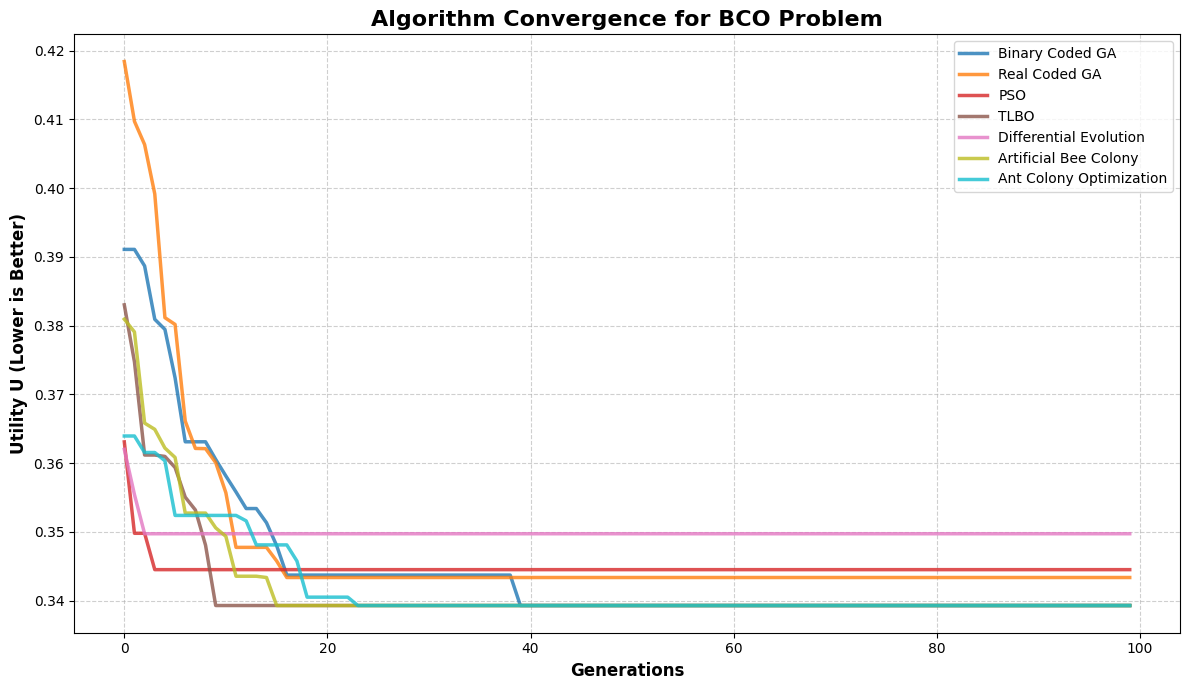

In [22]:
# ==========================================
# 4. Execute Simulation
# ==========================================
validators = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02,
              138.59, 207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89,
              121.47, 198.76, 254.19, 167.43, 289.05, 132.88]

# Ek single run karenge deep generation setup ke sath curve dekhne ke liye
run_bcop_experiment(validators)

--- Running Enhanced BCOP Experiment (100 Generations) ---
[Binary Coded GA] Best Utility: 0.34262 | Execution Time: 0.58s
[Real Coded GA] Best Utility: 0.35129 | Execution Time: 0.61s
[PSO] Best Utility: 0.34607 | Execution Time: 0.68s
[TLBO] Best Utility: 0.34262 | Execution Time: 1.40s
[Differential Evolution] Best Utility: 0.34918 | Execution Time: 0.78s
[Artificial Bee Colony] Best Utility: 0.34262 | Execution Time: 2.00s
[Ant Colony Optimization] Best Utility: 0.35448 | Execution Time: 13.66s


C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_10100\1075455133.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(histories)).colors


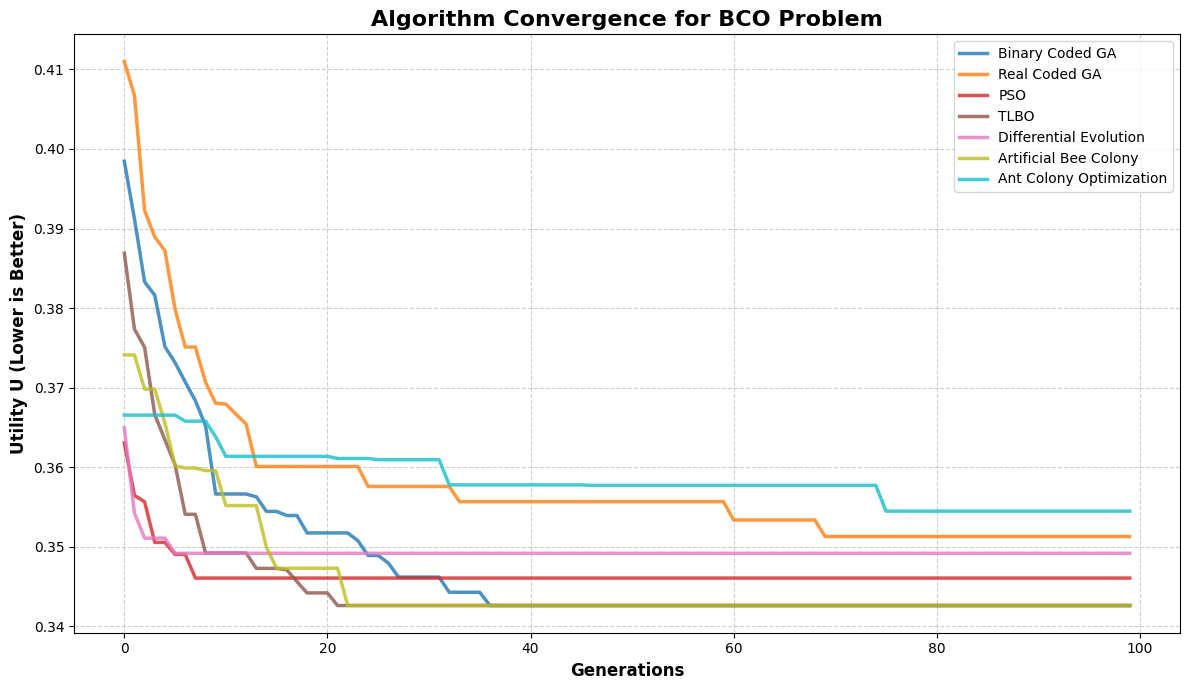

In [23]:
# ==========================================
# 4. Execute Simulation
# ==========================================
validators = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58,
255.98, 249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22,
153.01, 116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63,
115.13, 236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30,
104.61 ]

# Ek single run karenge deep generation setup ke sath curve dekhne ke liye
run_bcop_experiment(validators)

--- Running Enhanced BCOP Experiment (100 Generations) ---
[Binary Coded GA] Best Utility: 0.34573 | Execution Time: 1.07s
[Real Coded GA] Best Utility: 0.35628 | Execution Time: 0.82s
[PSO] Best Utility: 0.35366 | Execution Time: 0.51s
[TLBO] Best Utility: 0.34694 | Execution Time: 1.67s
[Differential Evolution] Best Utility: 0.35948 | Execution Time: 1.16s
[Artificial Bee Colony] Best Utility: 0.34573 | Execution Time: 2.52s
[Ant Colony Optimization] Best Utility: 0.36506 | Execution Time: 22.42s


C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_10100\1075455133.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(histories)).colors


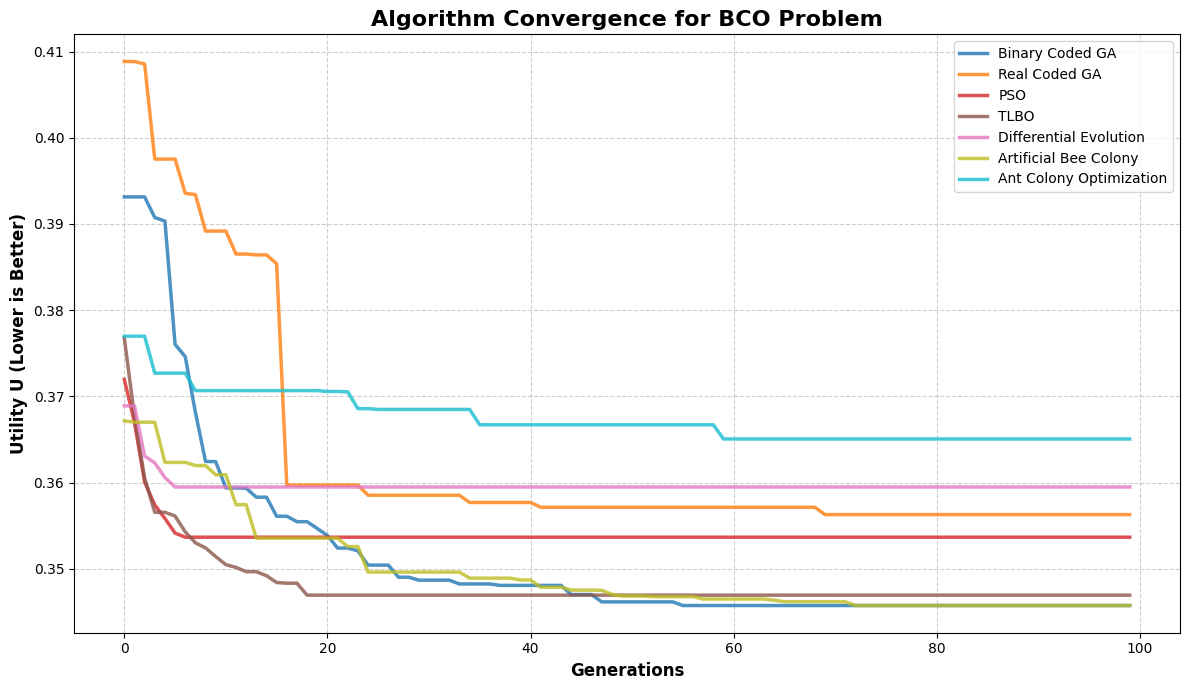

In [24]:
validators = [
    174.91, 290.14, 246.40, 219.73, 131.20, 131.19, 111.62, 273.23, 220.22, 241.61,
    104.12, 293.98, 266.49, 142.47, 136.36, 136.68, 160.92, 204.91, 186.38, 158.24,
    222.37, 127.89, 158.43, 191.24, 190.22, 116.15, 202.85, 219.26, 218.42, 109.29,
    158.42, 113.01, 118.97, 289.43, 293.10, 261.73, 160.91, 118.04, 236.98, 188.05,
    124.41, 106.90, 281.33, 101.40, 113.00, 100.10, 273.05, 142.04, 209.64, 113.37,
    161.47, 134.42, 100.17, 283.31, 290.62, 174.05, 158.55, 231.81, 139.11, 248.65
]

run_bcop_experiment(validators)

--- Running Enhanced BCOP Experiment (100 Generations) ---
[Binary Coded GA] Best Utility: 0.34840 | Execution Time: 0.65s
[Real Coded GA] Best Utility: 0.35674 | Execution Time: 0.61s
[PSO] Best Utility: 0.35576 | Execution Time: 0.57s
[TLBO] Best Utility: 0.34994 | Execution Time: 1.43s
[Differential Evolution] Best Utility: 0.35636 | Execution Time: 0.87s
[Artificial Bee Colony] Best Utility: 0.34872 | Execution Time: 2.50s
[Ant Colony Optimization] Best Utility: 0.36106 | Execution Time: 25.66s


C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_10100\1075455133.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(histories)).colors


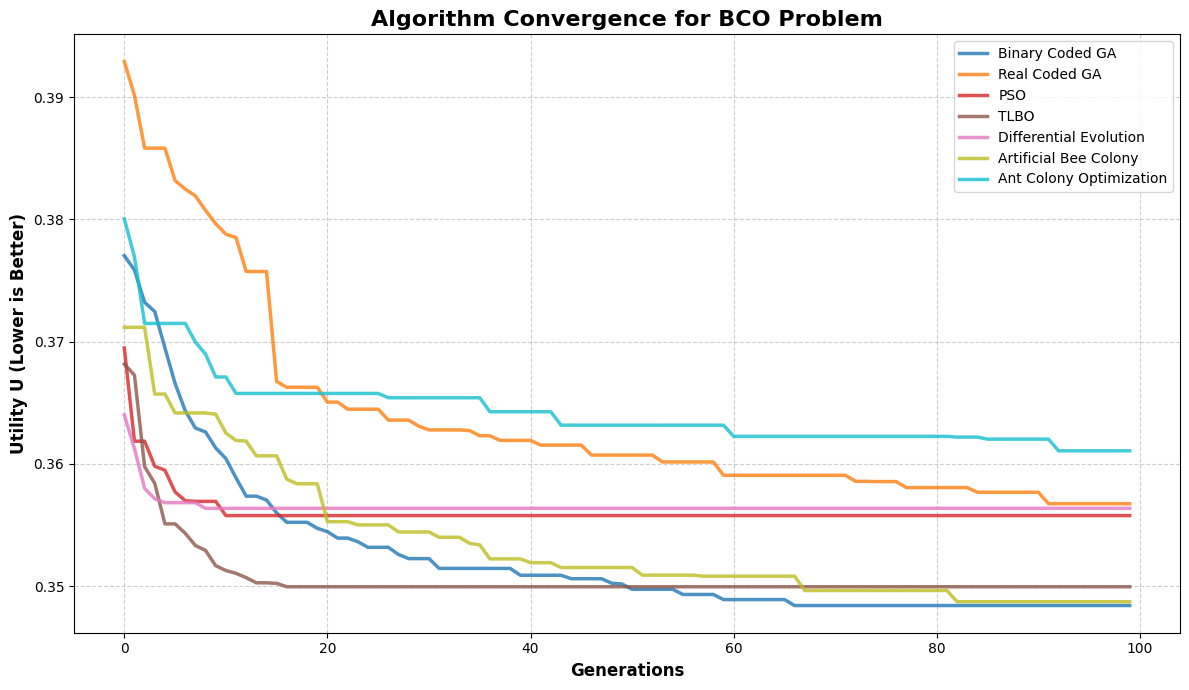

In [25]:
validators = [
    177.74, 154.27, 265.75, 171.35, 156.19, 103.58, 269.83, 140.23, 276.10, 192.36,
    275.60, 115.65, 295.66, 242.06, 127.42, 112.56, 115.11, 249.20, 246.33, 243.68,
    229.07, 150.91, 110.15, 275.98, 151.05, 128.79, 169.57, 151.01, 149.33, 240.24,
    188.16, 247.96, 146.47, 255.45, 117.72, 191.07, 287.89, 211.53, 138.81, 268.04,
    109.11, 122.95, 171.13, 284.14, 258.91, 180.70, 109.68, 133.00, 240.16, 113.43,
    104.93, 226.78, 145.41, 248.33, 170.83, 265.55, 123.63, 221.72, 176.60, 162.83,
    203.24, 240.35, 205.80, 242.54, 227.17, 202.93, 117.20, 181.72, 121.78, 199.53,
    223.77, 205.08, 113.62, 100.99, 134.11, 259.04, 276.51, 158.48, 107.03, 159.27
]

run_bcop_experiment(validators)

--- Running Enhanced BCOP Experiment (100 Generations) ---
[Binary Coded GA] Best Utility: 0.35126 | Execution Time: 0.66s
[Real Coded GA] Best Utility: 0.36588 | Execution Time: 0.88s
[PSO] Best Utility: 0.36191 | Execution Time: 0.56s
[TLBO] Best Utility: 0.35232 | Execution Time: 1.64s
[Differential Evolution] Best Utility: 0.36424 | Execution Time: 1.19s
[Artificial Bee Colony] Best Utility: 0.35244 | Execution Time: 2.54s
[Ant Colony Optimization] Best Utility: 0.36086 | Execution Time: 32.40s


C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_10100\1075455133.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(histories)).colors


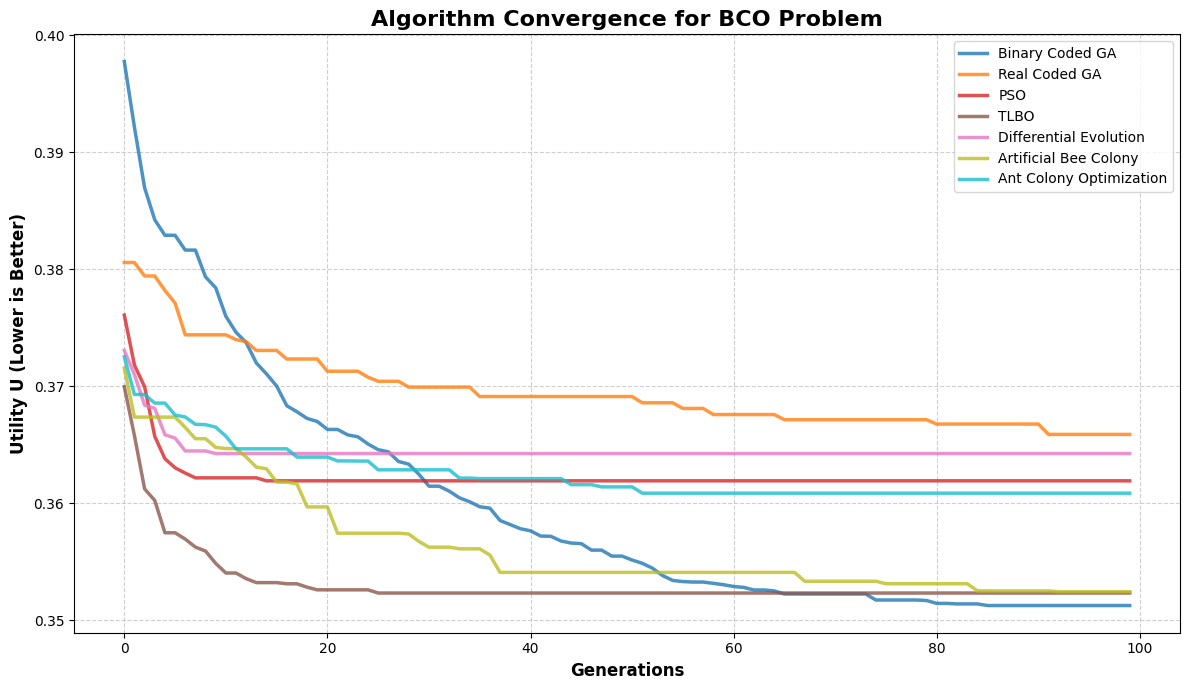

In [26]:
validators = [
    292.49, 150.36, 199.45, 160.18, 156.97, 181.02, 105.10, 247.51, 208.76, 244.31,
    278.43, 280.95, 266.38, 256.71, 122.18, 159.98, 236.42, 237.93, 137.49, 170.36,
    132.89, 221.11, 250.77, 290.47, 164.71, 202.66, 173.20, 294.67, 211.19, 156.12,
    258.98, 175.76, 232.08, 196.24, 225.10, 179.91, 103.79, 153.25, 248.86, 210.05,
    173.34, 190.10, 293.43, 160.03, 242.13, 208.41, 141.07, 124.64, 185.76, 226.79,
    109.11, 110.22, 143.06, 113.64, 241.07, 239.53, 131.02, 217.47, 132.50, 172.93,
    223.36, 142.00, 220.15, 120.73, 241.61, 274.57, 145.71, 280.12, 165.75, 293.07,
    106.88, 183.02, 187.97, 114.71, 212.16, 215.17, 118.80, 267.89, 121.23, 202.34,
    142.17, 150.36, 283.33, 178.69, 179.52, 256.40, 143.43, 150.05, 147.16, 297.05,
    203.35, 111.44, 174.91, 124.97, 231.29, 264.48, 102.67, 107.03, 136.98, 159.69
]

run_bcop_experiment(validators)